In [ ]:
!py -m pip install lightgbm -q

In [ ]:
!py -m pip install shap -q

In [5]:
!py -m pip install pyTsetlinMachineParallel

  Using cached pyTsetlinMachineParallel-0.2.1.tar.gz (19 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Running setup.py clean for pyTsetlinMachineParallel
Failed to build pyTsetlinMachineParallel


  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> [26 lines of output]
      running bdist_wheel
      running build
      running build_py
      creating build\lib.win-amd64-cpython-312\pyTsetlinMachineParallel
      copying pyTsetlinMachineParallel\tm.py -> build\lib.win-amd64-cpython-312\pyTsetlinMachineParallel
      copying pyTsetlinMachineParallel\tools.py -> build\lib.win-amd64-cpython-312\pyTsetlinMachineParallel
      copying pyTsetlinMachineParallel\__init__.py -> build\lib.win-amd64-cpython-312\pyTsetlinMachineParallel
      running build_ext
      building 'libTM' extension
      creating build\temp.win-amd64-cpython-312\Release\pyTsetlinMachineParallel
      "C:\Program Files (x86)\Microsoft Visual Studio\18\BuildTools\VC\Tools\MSVC\14.50.35717\bin\HostX86\x64\cl.exe" /c /nologo /O2 /W3 /GL /DNDEBUG /MD -IpyTsetlinMachineParallel -IC:\Users\manoj\AppData\Local\Programs\Python\Python312\include -IC:\Use

In [17]:
import pandas as pd

df = pd.read_csv("D:\mycode\Fintech-agent\data\macro\combined_macro_data.csv", parse_dates=["date"])

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
C:\Users\manoj\AppData\Local\Temp\ipykernel_17236\385521888.py:3: SyntaxWarning: invalid escape sequence '\m'
  df = pd.read_csv("D:\mycode\Fintech-agent\data\macro\combined_macro_data.csv", parse_dates=["date"])


In [4]:
from pyTsetlinMachineParallel.tm import RegressionTsetlinMachine

ModuleNotFoundError: No module named 'pyTsetlinMachineParallel'

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.decomposition import PCA
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import warnings
from sklearn.inspection import permutation_importance
import shap

### pipeline 

In [6]:
def add_lag_features(X_df, lag_cols, lags=[1, 2, 4]):
    X = X_df.copy()
    for col in lag_cols:
        if col in X.columns:
            for lag in lags:
                X[f"{col}_lag{lag}"] = X[col].shift(lag)
    return X

In [7]:
def add_rolling_features(X_df, roll_cols, windows=[2, 4]):
    X = X_df.copy()
    for col in roll_cols:
        if col in X.columns:
            for w in windows:
                X[f"{col}_roll{w}"] = X[col].shift(1).rolling(w).mean()
    return X

In [20]:
def get_model(model_name):
    models = {
        'RF':       RandomForestRegressor(
                        n_estimators=500, max_depth=5,
                        min_samples_leaf=3, random_state=42),
        'GB':       GradientBoostingRegressor(
                        n_estimators=300, learning_rate=0.05,
                        max_depth=3, min_samples_leaf=3,
                        subsample=0.8, random_state=42),
        'XGB':      XGBRegressor(
                        n_estimators=500, learning_rate=0.03,
                        max_depth=3, subsample=0.7,
                        colsample_bytree=0.7, reg_alpha=0.1,
                        reg_lambda=1.0, random_state=42,
                        objective='reg:squarederror'),
        'KNN':      KNeighborsRegressor(n_neighbors=7, weights='distance'),
        'SVR':      SVR(kernel='rbf', C=10.0, epsilon=0.01, gamma='scale'),
        'bayes':    BayesianRidge(max_iter=500),
        'catboost': CatBoostRegressor(
                        iterations=500, learning_rate=0.03, depth=4,
                        l2_leaf_reg=5.0, random_state=42, verbose=0)
    }
    return models[model_name]

In [21]:

def standard_importance(fitted_model, pipeline, X_train, y_train, feature_names):
    if hasattr(fitted_model, 'feature_importances_'):
        importances = fitted_model.feature_importances_
    elif hasattr(fitted_model, 'coef_'):
        importances = np.abs(fitted_model.coef_)
    else:
        perm        = permutation_importance(pipeline, X_train, y_train,
                                             n_repeats=10, random_state=42)
        importances = perm.importances_mean
 
    return pd.DataFrame({
        'feature':    feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True)
 

In [22]:
def shap_importance(fitted_model, X_train, feature_names):
    X_train_df = pd.DataFrame(X_train, columns=feature_names)
 
    tree_models = (RandomForestRegressor, GradientBoostingRegressor,
                   XGBRegressor, CatBoostRegressor)
 
    if isinstance(fitted_model, tree_models):
        explainer   = shap.TreeExplainer(fitted_model)
        shap_values = explainer.shap_values(X_train_df)
    else:
        explainer   = shap.KernelExplainer(
            fitted_model.predict,
            shap.sample(X_train_df, 50)
        )
        shap_values = explainer.shap_values(X_train_df)
 
    importances = np.abs(shap_values).mean(axis=0)
 
    return pd.DataFrame({
        'feature':    feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True), shap_values, X_train_df

In [23]:
def permutation_importance_ranked(pipeline, X_train, y_train, feature_names):
    perm        = permutation_importance(pipeline, X_train, y_train,
                                         n_repeats=20, random_state=42)
    importances = perm.importances_mean
    std         = perm.importances_std
 
    return pd.DataFrame({
        'feature':    feature_names,
        'importance': importances,
        'std':        std
    }).sort_values('importance', ascending=False).reset_index(drop=True)
 
 

In [24]:
def plot_standard(fi_df, macro_vars, macro_fi, other_fi, model_name, use_macro, ax_list):
    ax_idx = 0
    if use_macro and not macro_fi.empty:
        ax_list[ax_idx].barh(macro_fi['feature'][::-1], macro_fi['importance'][::-1], color='steelblue')
        ax_list[ax_idx].set_title(f"Standard — Macro\n({model_name})")
        ax_list[ax_idx].set_xlabel("Importance")
        ax_list[ax_idx].grid(True, alpha=0.3)
        ax_idx += 1
    if not other_fi.empty:
        ax_list[ax_idx].barh(other_fi['feature'][::-1], other_fi['importance'][::-1], color='darkorange')
        ax_list[ax_idx].set_title(f"Standard — Other\n({model_name})")
        ax_list[ax_idx].set_xlabel("Importance")
        ax_list[ax_idx].grid(True, alpha=0.3)
 

In [25]:
def plot_shap(shap_values, X_train_df, fi_df, model_name):
    plt.figure()
    shap.summary_plot(shap_values, X_train_df, plot_type="bar", show=False)
    plt.title(f"SHAP — Mean |SHAP| ({model_name})")
    plt.tight_layout()
    plt.show()
 
    plt.figure()
    shap.summary_plot(shap_values, X_train_df, show=False)
    plt.title(f"SHAP — Direction & Magnitude ({model_name})")
    plt.tight_layout()
    plt.show()
 

In [26]:
def plot_permutation(fi_df, model_name):
    fig_perm, ax = plt.subplots(figsize=(7, max(4, len(fi_df) * 0.3)))
    top = fi_df.head(20)
    ax.barh(top['feature'][::-1], top['importance'][::-1],
            xerr=top['std'][::-1] if 'std' in top.columns else None,
            color='mediumseagreen', capsize=3)
    ax.set_title(f"Permutation Importance — Top 20\n({model_name})")
    ax.set_xlabel("Mean accuracy decrease (±std)")
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
 
 

In [27]:

def compute_and_plot_importance(strategy, fitted_model, pipeline,
                                X_train, y_train, feature_names,
                                macro_vars, model_name, use_macro):
 
    def split_macro_other(fi_df):
        macro_fi = fi_df[fi_df['feature'].apply(
            lambda f: any(f == m or f.startswith(m + "_") for m in macro_vars)
        )].reset_index(drop=True)
        other_fi = fi_df[~fi_df.index.isin(macro_fi.index)].reset_index(drop=True)
        return macro_fi, other_fi
 
    run_standard    = strategy in ('standard', 'all')
    run_shap        = strategy in ('shap',     'all')
    run_permutation = strategy in ('permutation', 'all')
 
    fi_standard = fi_shap = fi_perm = None
 
    if run_standard:
        fi_standard          = standard_importance(fitted_model, pipeline,
                                                   X_train, y_train, feature_names)
        macro_fi, other_fi   = split_macro_other(fi_standard)
        n_std_plots          = (1 if use_macro and not macro_fi.empty else 0) + \
                               (1 if not other_fi.empty else 0)
        if n_std_plots > 0:
            fig_std, axes_std = plt.subplots(1, n_std_plots,
                                             figsize=(6 * n_std_plots, 5))
            axes_std = np.array(axes_std).flatten()
            plot_standard(fi_standard, macro_vars, macro_fi, other_fi,
                          model_name, use_macro, axes_std)
            plt.suptitle(f"Standard Importance | {model_name}", fontsize=12, fontweight='bold')
            plt.tight_layout()
            plt.show()
 
    if run_shap:
        fi_shap, shap_values, X_train_df = shap_importance(fitted_model, X_train, feature_names)
        plot_shap(shap_values, X_train_df, fi_shap, model_name)
 
    if run_permutation:
        fi_perm = permutation_importance_ranked(pipeline, X_train, y_train, feature_names)
        plot_permutation(fi_perm, model_name)
 
    return fi_standard, fi_shap, fi_perm
 

In [30]:

def CPI_prediction(data, use_macro, model,
                   use_scaling, test_quarters=8,
                   use_lags=True, use_rolling=True,
                   feature_selection=False, n_features=15,
                   importance_strategy='standard'):
 
    macro_vars = [
        "wti_price","fedfunds","nfci","anfci","nfci_risk","nfci_credit",
        "nfci_leverage","nfci_nonfinancial_leverage","gdp","ppi",
        "trade_balance","unrate","usd_index"
    ]
 
    df = data.copy().sort_values("date").reset_index(drop=True)
 
    if use_lags:
        for lag in [1, 2, 4]:
            df[f"cpiret_lag{lag}"] = df["cpiret"].shift(lag)
        for col in macro_vars:
            if col in df.columns:
                df[f"{col}_lag1"] = df[col].shift(1)
 
    if use_rolling:
        for w in [2, 4]:
            df[f"cpiret_roll{w}"] = df["cpiret"].shift(1).rolling(w).mean()
 
    df = df.dropna().reset_index(drop=True)
    dates = df["date"]
 
    X = df.drop(columns=["cpiret", "date"])
    y = df["cpiret"]
 
    if not use_macro:
        drop_cols = macro_vars + [c for c in X.columns
                                  if any(c.startswith(m) for m in macro_vars)]
        X = X.drop(columns=drop_cols, errors="ignore")
 
    X_train = X.iloc[:-test_quarters]
    X_test  = X.iloc[-test_quarters:]
    y_train = y.iloc[:-test_quarters]
    y_test  = y.iloc[-test_quarters:]
    test_dates    = dates.iloc[-test_quarters:]
    feature_names = X.columns.tolist()
 
    steps = []
    if use_scaling:
        steps.append(('scaler', RobustScaler()))
    if feature_selection:
        steps.append(('selector', SelectKBest(f_regression,
                                              k=min(n_features, X.shape[1]))))
    steps.append(('model', get_model(model)))
 
    pipeline = Pipeline(steps)
    pipeline.fit(X_train, y_train)
 
    predictions  = pipeline.predict(X_test)
    fitted_model = pipeline.named_steps['model']
 
    mse  = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, predictions)
    mape = mean_absolute_percentage_error(y_test, predictions) * 100
 
    results = pd.DataFrame({
        "date":             test_dates.values,
        "actual_cpiret":    y_test.values,
        "predicted_cpiret": predictions
    })
 
    print(f"\n{'='*65}")
    print(f"{'Date':<15} {'Actual':>12} {'Predicted':>12} {'Error':>12}")
    print(f"{'-'*65}")
    for _, row in results.iterrows():
        error = abs(row['actual_cpiret'] - row['predicted_cpiret'])
        print(f"{str(row['date'])[:10]:<15} {row['actual_cpiret']:>12.6f} {row['predicted_cpiret']:>12.6f} {error:>12.6f}")
    print(f"{'-'*65}")
    print(f"{'RMSE:':>45} {rmse:>12.6f}")
    print(f"{'MAPE (%):':>45} {mape:>12.2f}")
    print(f"{'R²:':>45} {r2:>12.4f}")
    print(f"{'='*65}")
 
    if feature_selection:
        selected_mask = pipeline.named_steps['selector'].get_support()
        feat_names_used = [f for f, s in zip(feature_names, selected_mask) if s]
        X_train_arr = pipeline[:-1].transform(X_train)
    else:
        feat_names_used = feature_names
        X_train_arr = pipeline[:-1].transform(X_train) if use_scaling else X_train.values
 
    fig_pred, ax_pred = plt.subplots(figsize=(10, 4))
    x = range(len(results))
    ax_pred.plot(x, results["actual_cpiret"],    marker="o", label="Actual",    linewidth=2)
    ax_pred.plot(x, results["predicted_cpiret"], marker="o", label="Predicted", linewidth=2)
    ax_pred.set_xticks(x)
    ax_pred.set_xticklabels([str(d)[:10] for d in results["date"]], rotation=45)
    ax_pred.set_xlabel("Quarter")
    ax_pred.set_ylabel("cpiret")
    ax_pred.set_title(f"CPI Prediction — {model}\n(R²={r2:.3f}  RMSE={rmse:.6f}  MAPE={mape:.1f}%)")
    ax_pred.legend()
    ax_pred.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
 
    fi_standard, fi_shap, fi_perm = compute_and_plot_importance(
        strategy          = importance_strategy,
        fitted_model      = fitted_model,
        pipeline          = pipeline,
        X_train           = X_train_arr,
        y_train           = y_train,
        feature_names     = feat_names_used,
        macro_vars        = macro_vars,
        model_name        = model,
        use_macro         = use_macro
    )
 
    return results, rmse, mape, r2, fi_standard, fi_shap, fi_perm

In [29]:
def CPI_prediction(data, use_macro, model,
                         use_scaling, test_quarters=8, 
                         use_lags=True, use_rolling=True,
                         feature_selection=False, n_features=15):

    macro_vars = [
        "wti_price","fedfunds","nfci","anfci","nfci_risk","nfci_credit",
        "nfci_leverage","nfci_nonfinancial_leverage","gdp","ppi",
        "trade_balance","unrate","usd_index"
    ]
 
    lag_target_cols  = ["cpiret"]
    roll_target_cols = ["cpiret"]
 
    df = data.copy().sort_values("date").reset_index(drop=True)
 
    if use_lags:
        for lag in [1, 2, 4]:
            df[f"cpiret_lag{lag}"] = df["cpiret"].shift(lag)
        for col in macro_vars:
            if col in df.columns:
                df[f"{col}_lag1"] = df[col].shift(1)
 
    if use_rolling:
        for w in [2, 4]:
            df[f"cpiret_roll{w}"] = df["cpiret"].shift(1).rolling(w).mean()
 
    df = df.dropna().reset_index(drop=True)
    dates = df["date"]
 
    X = df.drop(columns=["cpiret", "date"])
    y = df["cpiret"]
 
    if not use_macro:
        drop_cols = macro_vars + [c for c in X.columns
                                  if any(c.startswith(m) for m in macro_vars)]
        X = X.drop(columns=drop_cols, errors="ignore")
 
    X_train = X.iloc[:-test_quarters]
    X_test  = X.iloc[-test_quarters:]
    y_train = y.iloc[:-test_quarters]
    y_test  = y.iloc[-test_quarters:]
    test_dates    = dates.iloc[-test_quarters:]
    feature_names = X.columns.tolist()
 
    steps = []
 
    if use_scaling:
        steps.append(('scaler', RobustScaler()))
 
    if feature_selection:
        steps.append(('selector', SelectKBest(f_regression, k=min(n_features, X.shape[1]))))
 
    steps.append(('model', get_model(model)))
    pipeline = Pipeline(steps)
    pipeline.fit(X_train, y_train)
 
    predictions  = pipeline.predict(X_test)
    fitted_model = pipeline.named_steps['model']
 
    mse  = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, predictions)
    mape = mean_absolute_percentage_error(y_test, predictions) * 100
 
    results = pd.DataFrame({
        "date":             test_dates.values,
        "actual_cpiret":    y_test.values,
        "predicted_cpiret": predictions
    })
 
    print(f"\n{'='*65}")
    print(f"{'Date':<15} {'Actual':>12} {'Predicted':>12} {'Error':>12}")
    print(f"{'-'*65}")
    for _, row in results.iterrows():
        error = abs(row['actual_cpiret'] - row['predicted_cpiret'])
        print(f"{str(row['date'])[:10]:<15} {row['actual_cpiret']:>12.6f} {row['predicted_cpiret']:>12.6f} {error:>12.6f}")
    print(f"{'-'*65}")
    print(f"{'RMSE:':>45} {rmse:>12.6f}")
    print(f"{'MAPE (%):':>45} {mape:>12.2f}")
    print(f"{'R²:':>45} {r2:>12.4f}")
    print(f"{'='*65}")
 
    if feature_selection:
        selector      = pipeline.named_steps['selector']
        selected_mask = selector.get_support()
        feat_names_used = [f for f, s in zip(feature_names, selected_mask) if s]
    else:
        feat_names_used = feature_names
 
    if hasattr(fitted_model, 'feature_importances_'):
        importances = fitted_model.feature_importances_
    elif hasattr(fitted_model, 'coef_'):
        importances = np.abs(fitted_model.coef_)
    else:
        perm        = permutation_importance(pipeline, X_train, y_train,
                                             n_repeats=10, random_state=42)
        importances = perm.importances_mean
        if feature_selection:
            importances = importances[selected_mask]
 
    fi_df = pd.DataFrame({
        'feature':    feat_names_used,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True)
 
    macro_fi = fi_df[fi_df['feature'].apply(
        lambda f: any(f == m or f.startswith(m + "_") for m in macro_vars)
    )].reset_index(drop=True)
    other_fi = fi_df[~fi_df.index.isin(macro_fi.index)].reset_index(drop=True)
 
    n_plots = 1 + (1 if use_macro and not macro_fi.empty else 0) + (1 if not other_fi.empty else 0)
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
    axes = np.array(axes).flatten()
    ax_idx = 0
 
    x = range(len(results))
    axes[ax_idx].plot(x, results["actual_cpiret"],    marker="o", label="Actual",    linewidth=2)
    axes[ax_idx].plot(x, results["predicted_cpiret"], marker="o", label="Predicted", linewidth=2)
    axes[ax_idx].set_xticks(x)
    axes[ax_idx].set_xticklabels([str(d)[:10] for d in results["date"]], rotation=45)
    axes[ax_idx].set_xlabel("Quarter")
    axes[ax_idx].set_ylabel("cpiret")
    axes[ax_idx].set_title(f"CPI Prediction — {model}\n(R²={r2:.3f}  RMSE={rmse:.6f}  MAPE={mape:.1f}%)")
    axes[ax_idx].legend()
    axes[ax_idx].grid(True, alpha=0.3)
    ax_idx += 1
 
    if use_macro and not macro_fi.empty:
        axes[ax_idx].barh(macro_fi['feature'][::-1], macro_fi['importance'][::-1], color='steelblue')
        axes[ax_idx].set_title(f"Macro Feature Importance\n({model})")
        axes[ax_idx].set_xlabel("Importance")
        axes[ax_idx].grid(True, alpha=0.3)
        ax_idx += 1
 
    if not other_fi.empty:
        axes[ax_idx].barh(other_fi['feature'][::-1], other_fi['importance'][::-1], color='darkorange')
        axes[ax_idx].set_title(f"Other Feature Importance\n({model})")
        axes[ax_idx].set_xlabel("Importance")
        axes[ax_idx].grid(True, alpha=0.3)
        ax_idx += 1
 
    for j in range(ax_idx, len(axes)):
        axes[j].set_visible(False)
 
    macro_label = "With Macro" if use_macro else "Without Macro"
    plt.suptitle(f"{model} | {macro_label} | Lags={use_lags} | Rolling={use_rolling}",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
 
    return results, rmse, mape, r2


### XGB


Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.009485     0.007493
2023-06-30          0.010843     0.011503     0.000660
2023-09-30          0.008784     0.005803     0.002981
2023-12-31         -0.003388     0.004448     0.007836
2024-03-31          0.018211     0.010774     0.007437
2024-06-30          0.005901     0.010128     0.004227
2024-09-30          0.003584     0.006058     0.002474
2024-12-31          0.000964     0.005613     0.004649
-----------------------------------------------------------------
                                        RMSE:     0.005336
                                    MAPE (%):       122.40
                                          R²:       0.4249


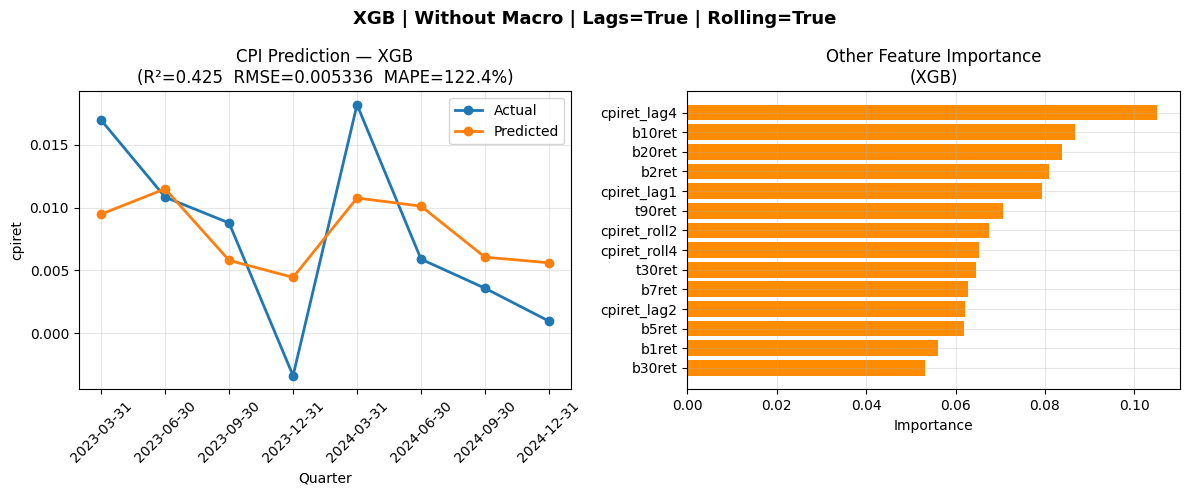

In [25]:
results, rmse, mape, r2 = CPI_prediction(
    df,
    use_macro=False,
    model='XGB',
    use_scaling=True,
    test_quarters=8,
    use_lags=True,
    use_rolling=True,
    feature_selection=False
)


Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.007600     0.009378
2023-06-30          0.010843     0.009623     0.001220
2023-09-30          0.008784     0.006328     0.002456
2023-12-31         -0.003388     0.004197     0.007585
2024-03-31          0.018211     0.010048     0.008163
2024-06-30          0.005901     0.009440     0.003539
2024-09-30          0.003584     0.005962     0.002378
2024-12-31          0.000964     0.006550     0.005586
-----------------------------------------------------------------
                                        RMSE:     0.005799
                                    MAPE (%):       133.62
                                          R²:       0.3208


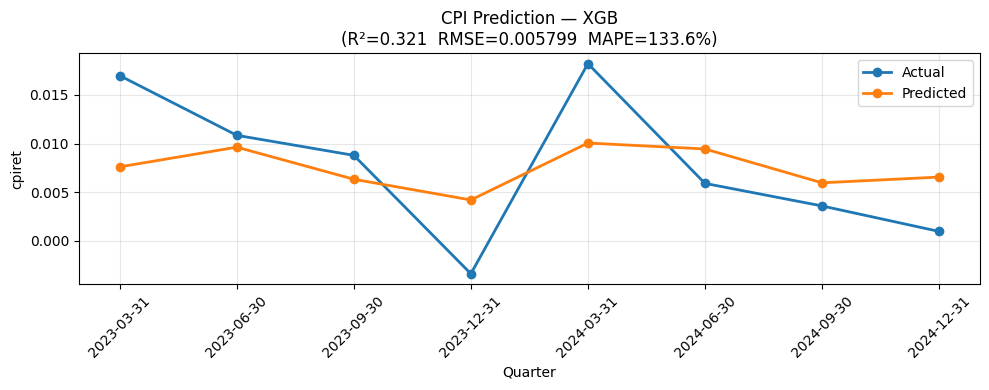

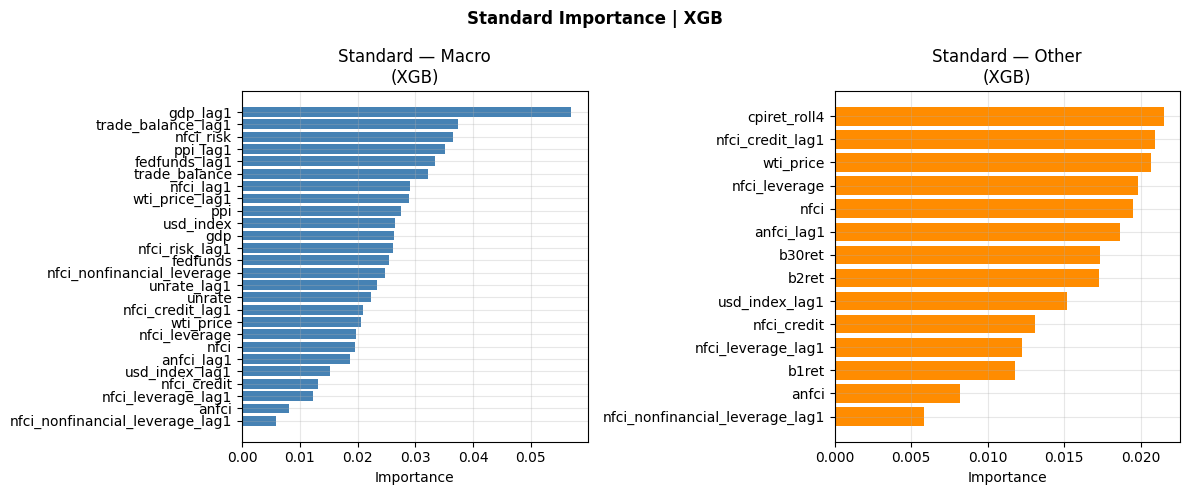

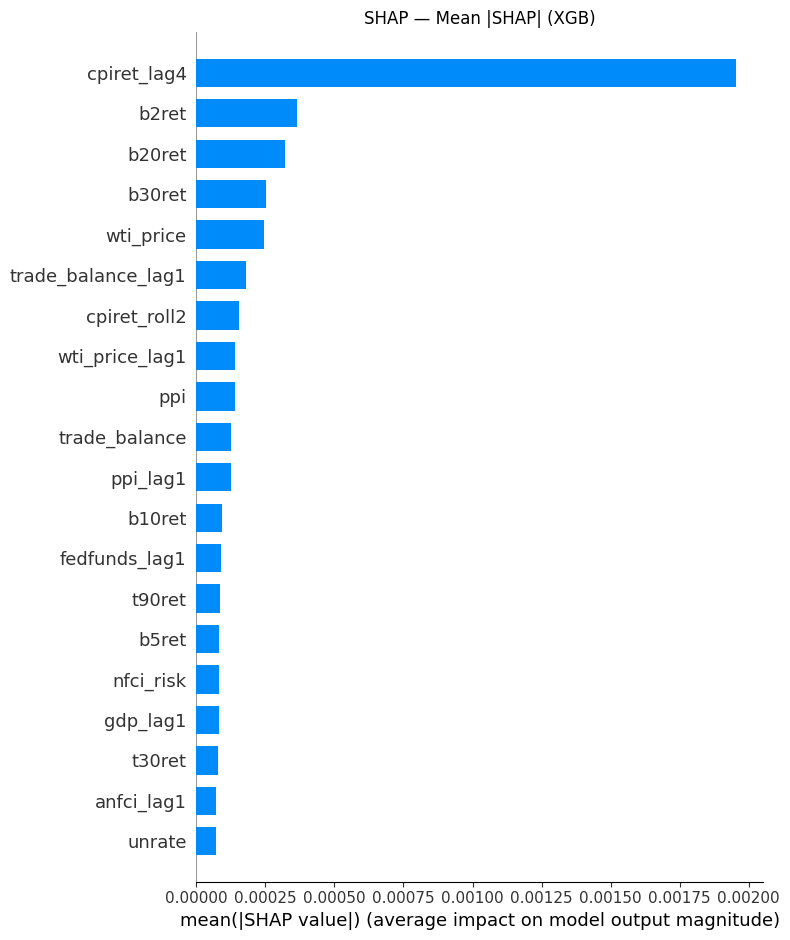

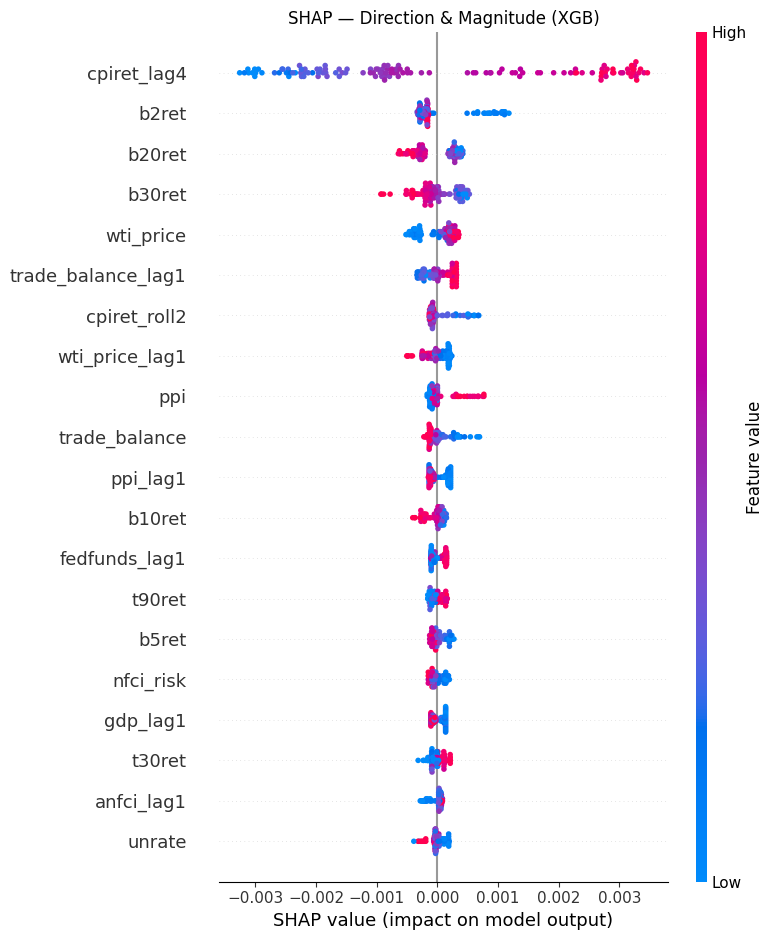

c:\Users\manoj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
c:\Users\manoj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
c:\Users\manoj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
c:\Users\manoj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
c:\Users\manoj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarni

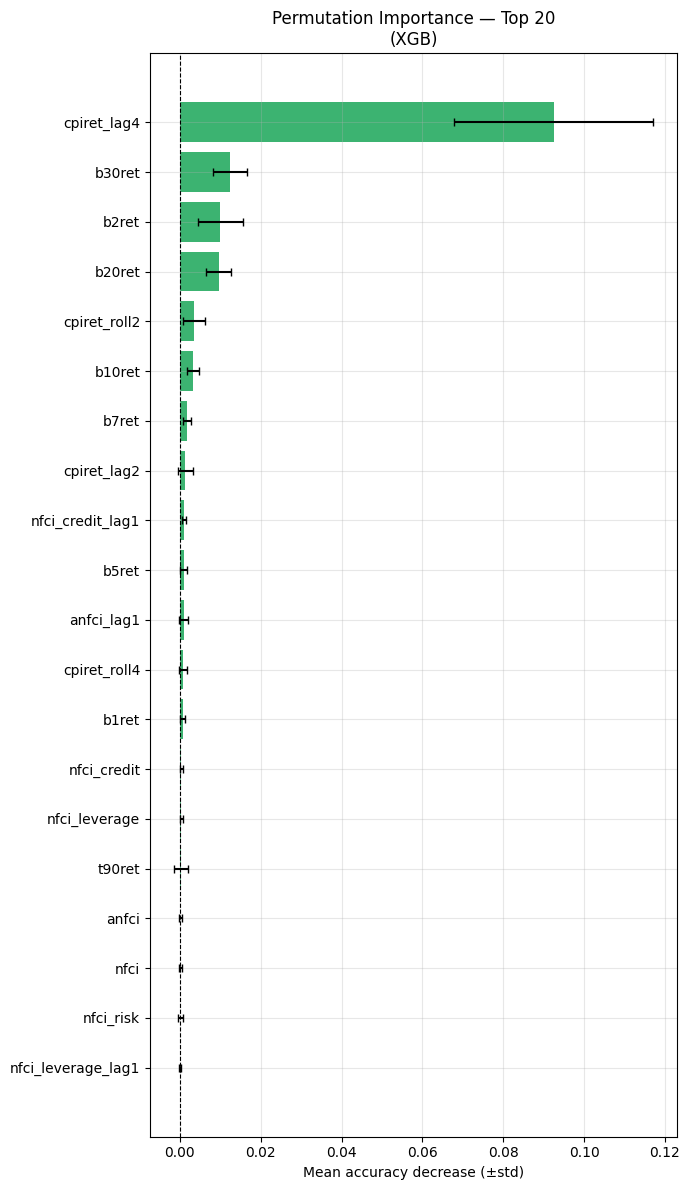

In [31]:
results, rmse, mape, r2, fi_std, fi_shap, fi_perm = CPI_prediction(
    df,
    use_macro=True,
    model='XGB',
    use_scaling=True,
    test_quarters=8,
    use_lags=True,
    use_rolling=True,
    importance_strategy='all'   # 'standard', 'shap', 'permutation', 'all'
)

### Catboost


Date                  Actual    Predicted        Error
-------------------------------------------------------
2023-03-31          0.016978     0.004933     0.012045
2023-06-30          0.010843     0.012485     0.001642
2023-09-30          0.008784     0.013474     0.004690
2023-12-31         -0.003388     0.004756     0.008144
2024-03-31          0.018211     0.009156     0.009055
2024-06-30          0.005901     0.008796     0.002895
2024-09-30          0.003584     0.005170     0.001586
2024-12-31          0.000964     0.009559     0.008595
-------------------------------------------------------
                                    MSE:     0.000050
                                     R²:      -0.0171


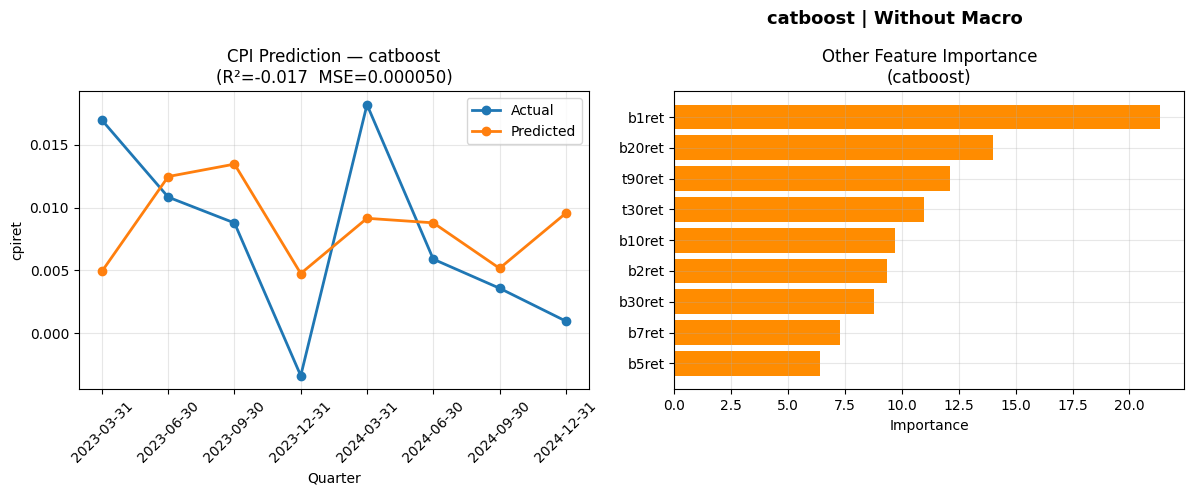

In [9]:

# Usage
results, mse, r2 = CPI_prediction(
    df,
    use_macro=False,
    model='catboost',
    use_scaling=True
)


Date                  Actual    Predicted        Error
-------------------------------------------------------
2023-03-31          0.016978     0.003300     0.013678
2023-06-30          0.010843     0.006335     0.004508
2023-09-30          0.008784     0.009092     0.000308
2023-12-31         -0.003388     0.005935     0.009323
2024-03-31          0.018211     0.007334     0.010877
2024-06-30          0.005901     0.007115     0.001214
2024-09-30          0.003584     0.010889     0.007305
2024-12-31          0.000964     0.014222     0.013258
-------------------------------------------------------
                                    MSE:     0.000080
                                     R²:      -0.6242


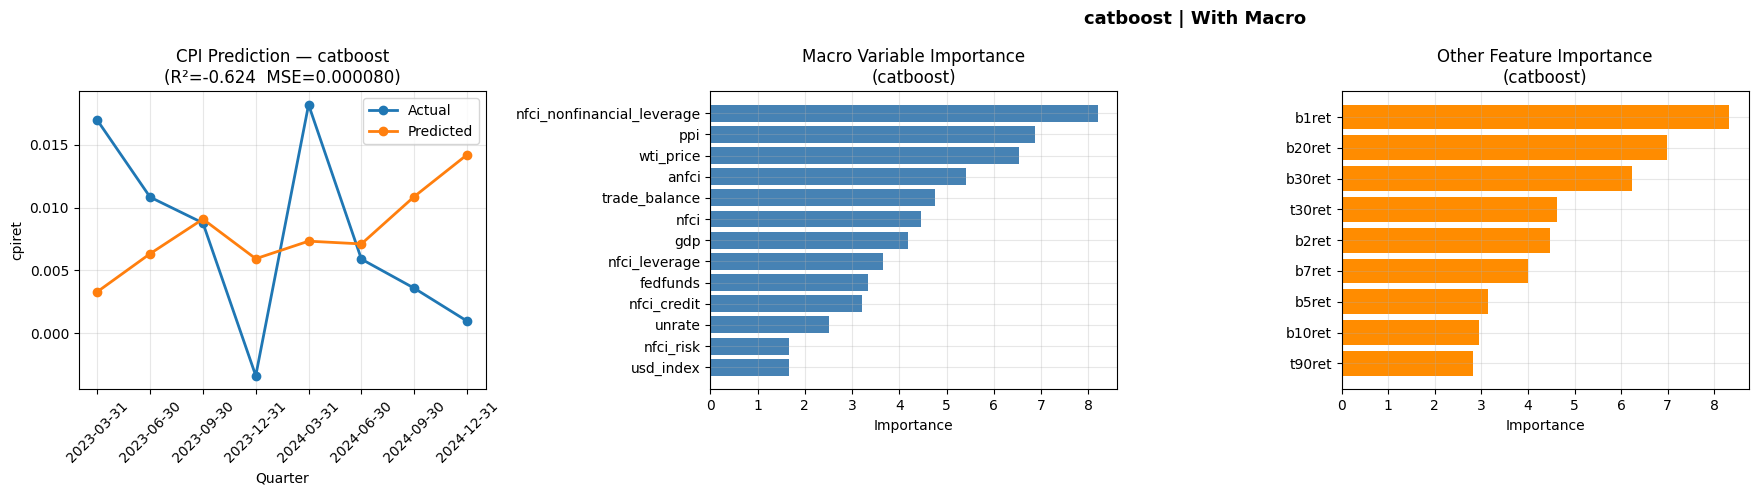

In [10]:

# Usage
results, mse, r2 = CPI_prediction(
    df,
    use_macro=True,
    model='catboost',
    use_scaling=True
)

### bayes


Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.014837     0.002141
2023-06-30          0.010843     0.021941     0.011098
2023-09-30          0.008784     0.008974     0.000190
2023-12-31         -0.003388    -0.001403     0.001985
2024-03-31          0.018211     0.013892     0.004319
2024-06-30          0.005901     0.011734     0.005833
2024-09-30          0.003584     0.003326     0.000258
2024-12-31          0.000964     0.006496     0.005532
-----------------------------------------------------------------
                                        RMSE:     0.005185
                                    MAPE (%):       109.92
                                          R²:       0.4570


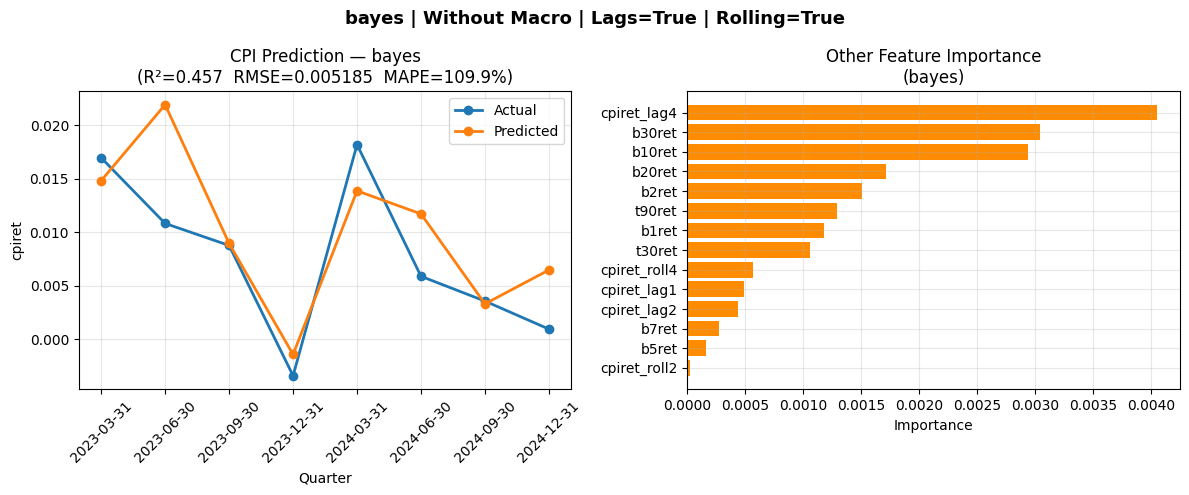

In [26]:
results, rmse, mape, r2 = CPI_prediction(
    df,
    use_macro=False,
    model='bayes',
    use_scaling=True,
    test_quarters=8,
    use_lags=True,
    use_rolling=True,
    feature_selection=False
)


Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.014168     0.002810
2023-06-30          0.010843     0.017415     0.006572
2023-09-30          0.008784     0.007130     0.001654
2023-12-31         -0.003388    -0.003199     0.000189
2024-03-31          0.018211     0.012263     0.005948
2024-06-30          0.005901     0.008183     0.002282
2024-09-30          0.003584     0.006037     0.002453
2024-12-31          0.000964     0.007264     0.006300
-----------------------------------------------------------------
                                        RMSE:     0.004186
                                    MAPE (%):       111.86
                                          R²:       0.6462


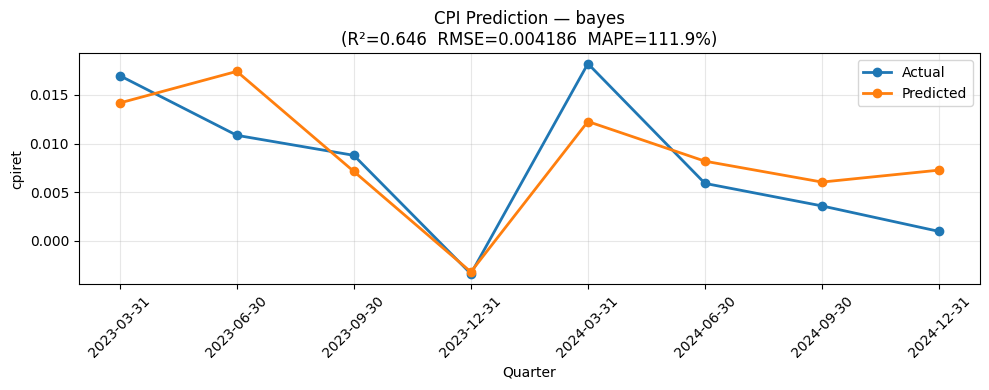

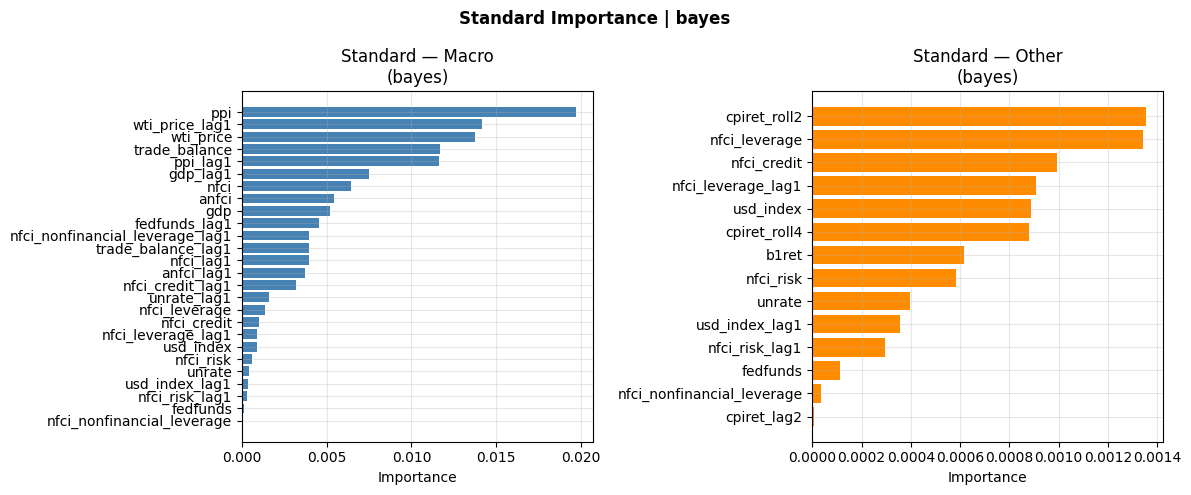

  0%|          | 0/128 [00:00<?, ?it/s]

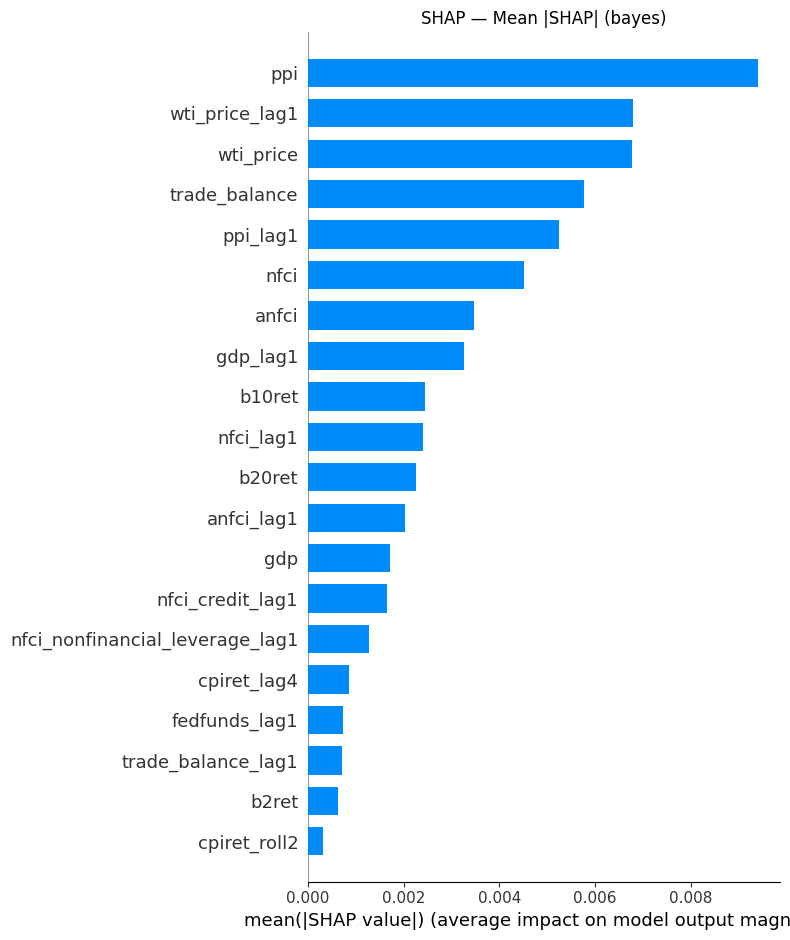

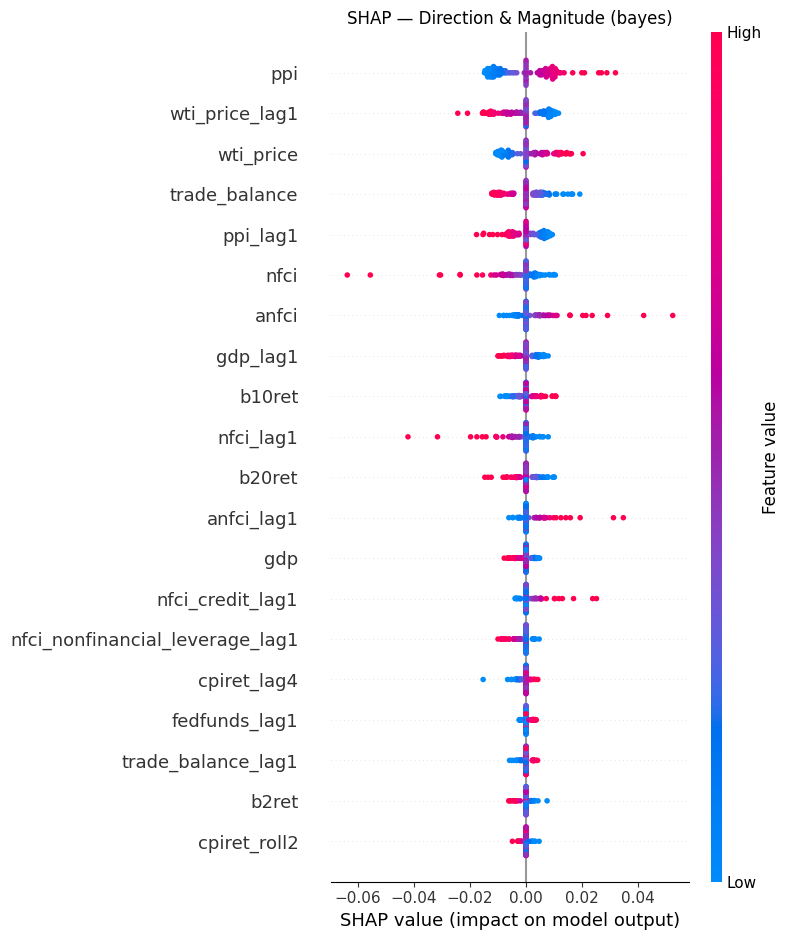

c:\Users\manoj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
c:\Users\manoj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
c:\Users\manoj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
c:\Users\manoj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
c:\Users\manoj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarni

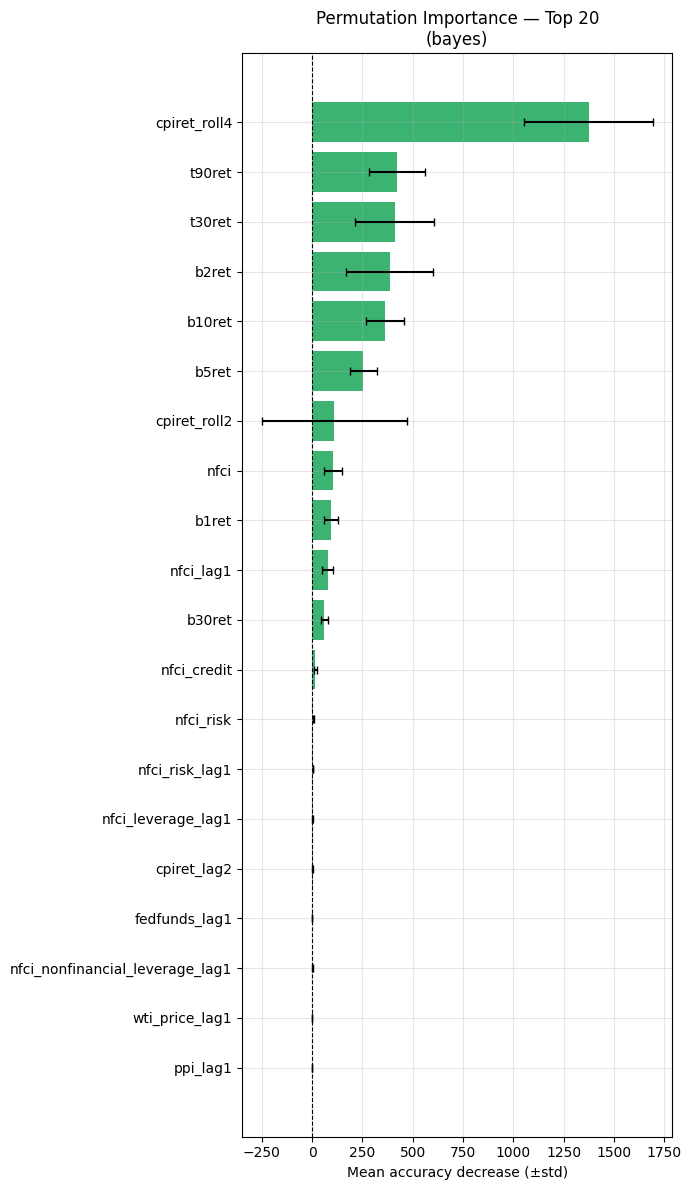

In [32]:
results, rmse, mape, r2, fi_std, fi_shap, fi_perm = CPI_prediction(
    df,
    use_macro=True,
    model='bayes',
    use_scaling=True,
    test_quarters=8,
    use_lags=True,
    use_rolling=True,
    importance_strategy='all'   # 'standard', 'shap', 'permutation', 'all'
)